## Setup

In [17]:
import os, re,json
import pandas as pd 
from tqdm import tqdm 
import matplotlib.pyplot as plt 
import numpy as np 
from wordcloud import WordCloud 
from collections import Counter,defaultdict 
from bs4 import BeautifulSoup, SoupStrainer
import unicodedata

TCP = '/Users/amycweng/DH/TCP'
metadataFolder = '../ECBC-Data-2022/TCP metadata'
main_folder = "../.."


def findTextTCP(id):
    if re.match('B1|B4',id[0:2]):
        path = f'{TCP}/P2{id[0:2]}/{id}.P4.xml'
    else: 
        if f'{id}.P4.xml' in os.listdir(f'{TCP}/P1{id[0:2]}'):
            path = f'{TCP}/P1{id[0:2]}/{id}.P4.xml'
        elif f'{id}.P4.xml' in os.listdir(f'{TCP}/P2{id[0:2]}'): 
            path = f'{TCP}/P2{id[0:2]}/{id}.P4.xml'
    return path 
def get_lang(filepath): 
    # read the input XML file 
    with open(filepath,'r') as file: 
        data = file.read()
    # use soupstrainer to only parse the main body
    tag = SoupStrainer("LANGUSAGE")
    soup = BeautifulSoup(data,features="xml",parse_only=tag)
    return soup.text
def visualize(x,y,title,xlabel,ylabel,color):
    plt.figure(figsize = (15, 10))
    plt.bar(x,y,color=color)
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=15)
    plt.xticks(np.arange(min(x), max(x)+1, 10.0), fontsize=12)
    plt.ylabel(ylabel, fontsize=15)
    plt.yticks(fontsize=10)
    plt.show()
def wordcloud(counts, title): 
    word_cloud = WordCloud(background_color = "white", width=3000, height=2000, max_words=1000, collocations=True).generate_from_frequencies(counts)
    plt.figure(figsize=(10,8))
    plt.imshow(word_cloud)
    plt.axis("off")
    plt.title(title,fontsize=18)
    plt.show()


import pandas as pd
catalog = pd.read_csv(f"{main_folder}/CORPUS/TCP_poetry.csv")
poems_tcpIDs = list(catalog['id'])
print(len(catalog))

catalog_all = pd.read_csv(f"{main_folder}/CORPUS/TCP_lines.csv")
lines_tcpIDs = list(catalog_all['id'])
print(len(catalog_all))

overlap = list(set(catalog['id']) & set(catalog_all['id']))
print(len(overlap))

sermon_div = pd.read_csv(f"{main_folder}/CORPUS/sermons.csv")['id'].tolist()
sermon_nondiv = pd.read_csv(f"{main_folder}/CORPUS/sermons_missing.csv")['id'].tolist()
sermons = sermon_div.copy()
sermons.extend(sermon_nondiv.copy())
print(len(sermons))

tcpIDs = poems_tcpIDs.copy()
tcpIDs.extend(lines_tcpIDs.copy())
tcpIDs = sorted(list(set(tcpIDs)))

def get_div_types_with_lines(fp): 
    with open(fp, "r", encoding="utf-8") as f:
        text = f.read()
    pattern = r"(DIV\d+\^[\w\^\\^]*)(?:.(?!DIV\d+\^))*?STARTLINE.*?(?=DIV\d+\^|$)"
    matches = re.findall(pattern, text, re.DOTALL)
    div_types = []
    for section in matches:
        section = re.sub(r"\\\^","_",section)
        div_type = section.split("^")[1]
        div_types.append(div_type)
    return div_types 

def get_div_report(tcpIDs): 
    div_types = defaultdict(int)
    for tcpID in tqdm(tcpIDs): 
        fps = []
        if tcpID in lines_tcpIDs and tcpID in poems_tcpIDs: 
            fps = [f"{main_folder}/plain_all/{tcpID}.txt", f"{main_folder}/plain/{tcpID}.txt"]
        elif tcpID in lines_tcpIDs: 
            fps = [f'../plain_all/{tcpID}.txt']
        else: 
            fps = [f'../plain/{tcpID}.txt']
        for fp in fps: 
            divs_with_lines = get_div_types_with_lines(fp)
            for div_type in divs_with_lines: 
                div_types[div_type] += 1 
    div_types_df = pd.DataFrame([{'div_type':x, 'count':y} for x,y in div_types.items()]).sort_values(by='count',ascending=False)
    return div_types_df

5304
18064
2815
5725


## Initial Filtering

In [ ]:
tcpID_subjects = {}
progress_bar = tqdm(tcpIDs)
for file in progress_bar:
    progress_bar.set_description(file)
    tcpID = file.split(".")[0]
    tcpID_subjects[tcpID] = []
    filepath = findTextTCP(tcpID)

    # read the input XML file 
    with open(filepath,'r',encoding='utf-8') as file: 
        data = file.read()
    # use soupstrainer to only parse the main body
    tag = SoupStrainer("KEYWORDS")
    soup = BeautifulSoup(data,features="xml",parse_only=tag)
    
    subjects = soup.find_all(['TERM'])
    for s in subjects: 
        tcpID_subjects[tcpID].append(s)

tcpID_subjects = {k:[item.string for item in v] for k,v in tcpID_subjects.items()}
with open("subject_headings.json",'w+') as file: 
    json.dump(tcpID_subjects,file)
tcpID_subjects_list = []
for subjects in tcpID_subjects.values():
    tcpID_subjects_list.extend(subjects)
top_subjects = Counter(tcpID_subjects_list).most_common(n=25)
print(top_subjects)

subjects_df = pd.DataFrame(sorted(dict(Counter(tcpID_subjects_list)).items(),key = lambda x:x[1],reverse=True),columns=["subject_heading","frequency"])
subjects_df.to_csv("APS/subject_headings.csv",index=False)
len(subjects_df)

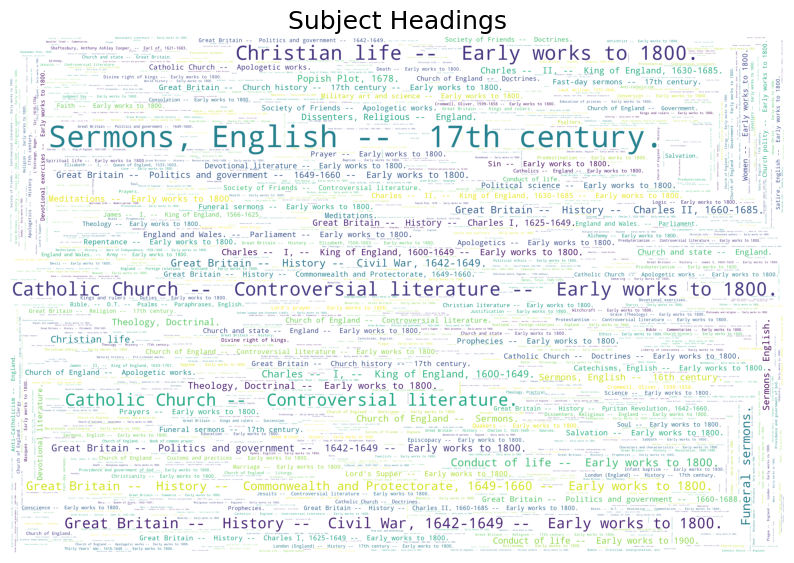

In [ ]:
with open("subject_headings.json",'r') as file: 
    tcpID_subjects = json.load(file)
tcpID_subjects_list = []
for tcpID, subjects in tcpID_subjects.items():
    if tcpID not in tcpIDs: continue 
    for subject in subjects: 
        subject = re.sub(" -- Early works to 1800","",subject)
        tcpID_subjects_list.append(subject)
wordcloud(Counter(tcpID_subjects_list),'Subject Headings')

In [ ]:
tcpIDs = pd.read_csv("APS_CORPUS_TO_CLUSTER.csv")['id']
tcpID_lang = {}
progress_bar = tqdm(sorted(tcpIDs))
for file in progress_bar:
    progress_bar.set_description(file)
    tcpID = file.split(".")[0]
    filepath = findTextTCP(tcpID)
    tcpID_lang[tcpID] = get_lang(filepath)
with open("tcpID_lang.json",'w+') as file: 
    json.dump(tcpID_lang,file)

B43856: 100%|██████████| 11456/11456 [12:05<00:00, 15.78it/s] 


In [16]:
top = Counter(tcpID_lang.values()).most_common(n=100)
print(top)

[('eng', 11215), ('lat', 129), ('wel', 56), ('sco', 20), ('fre', 20), ('ita', 5), ('frm', 4), ('mul', 2), ('spa', 1), ('roa', 1), ('por', 1), ('ger', 1), ('gla', 1)]


In [ ]:
subjects = pd.read_csv("subject_headings.csv")
with open(f"{main_folder}/CORPUS/subject_headings.json",'r') as file: 
    tcpID_subjects = json.load(file)
    
to_exclude = ['songs', 'broadsides', 'poetry', 'ballads', "poem","elegy",
              'medicine', 'navigation', 'gardening', 'astrology', 'drama',
            'wit and humor', 'almanacs', 'surgery', 'anatomy', 'comets',
                "advertising","booksellers","proverbs",
              "universities","floriculture","plants",
              "aphorisms","birds","fishes","metallurgy",
              "astrologers","gold","infertility","mineral waters","atlases",
              "commonplace-books","drawing","glass-painting","geography",
              "planispheres","etiquette","compass","weather","quotations, latin",
              "phrase books","charts","description and travel",
              "social life and customs","health resorts","nervous system",
              "wine and wine making","epigrams","music","madrigals","pediatrics",
              "biology",r"\bart --","medical",r"\bverse","humor",
              "geology","zoology","latin literature","latin language",
              "welsh language", "french language", "italian language",
              "spanish language",r"\bhabits\b","diseases","agriculture","travel",
              "smoke","numismatics","devices","plant","cosmetics","reptiles",
              "needlework","battles","therapeutic"]
for keyword in to_exclude: 
    subjects = subjects[~subjects["subject_heading"].str.contains(keyword,case=False)]
    # exclude = subjects[subjects["subject_heading"].str.contains(keyword,case=False)]
    # exclude.to_csv("APS/exclude.csv",index=False)
    subjects.to_csv("subject_headings.csv",index=False)
print(len(subjects))
to_exclude = '|'.join(re.escape(k) for k in to_exclude)


10107


In [ ]:
def clean_date(date): 
    date = str(date)
    if "?" in date: return -1 # THIS MIGHT BE A MISTAKE
    if "-" in date: 
        date = date.split("-")[0]
    if date in ['date', '169u', '16uu']: return -1  
    if int(date) > 1700: return -1  
    return int(date) 

target_subjects = pd.read_csv("subject_headings_target.csv")['subject_heading']
target_subjects = "|".join([re.escape(w) for w in target_subjects])

catalog = pd.read_csv(f"{main_folder}/CORPUS/TCP_poetry.csv")
catalog_all = pd.read_csv(f"{main_folder}/CORPUS/TCP_lines.csv")
catalog = catalog[['id','title','authors','publisher','pubplace','date']]
catalog_all = catalog_all[['id','title','authors','publisher','pubplace','date']]
APS = pd.concat([catalog,catalog_all])
APS = APS.drop_duplicates(subset='id', keep='first')
APS["subject_heading"] = APS['id'].map(lambda i: '; '.join(tcpID_subjects.get(i, [])))
ground, unknown = [],[]
APS = APS.to_dict(orient='records')

for item in tqdm(APS): 
    if item['id'] not in tcpID_lang: continue 
    if tcpID_lang[item['id']] != "eng": continue # Eng-lang only 
    date_check = False  
    date = clean_date(item['date'])
    if 1600 <= date <= 1660: 
        date_check = True 
    else: 
        authors = item['authors'].split("; ")
        aut_dates = [sorted(re.findall(r"\d+",aut)) for aut in authors]
        for aut_date in aut_dates: 
            aut_date = [int(d) for d in aut_date]
            if len(aut_date) == 1: # active before 1660 
                if 1600 <= aut_date[0] <= 1660: 
                    date_check = True 
            elif len(aut_date) > 1: 
                if not (aut_date[0] <= 1600 and aut_date[-1] <= 1600): 
                    # cannot be 16th century only 
                    if aut_date[0] <= 1660: # born/active before 1660 
                        date_check = True 
    if date_check: 
        if re.search(target_subjects,str(item['subject_heading'])): 
            ground.append(item)
        else: 
            unknown.append(item)

ground = pd.DataFrame(ground)
ground.to_csv("../CORPUS/APS_METADATA_ground.csv",index=False)
unknown = pd.DataFrame(unknown)
unknown.to_csv("../CORPUS/APS_METADATA_unknown.csv",index=False)

print(ground)
print(unknown)

100%|██████████| 20553/20553 [00:00<00:00, 283939.76it/s]


        id                                              title  \
0   B08803  Several discourses concerning the actual Provi...   
1   B08178  The treasure of true loue or A liuely descript...   
2   A95924  Theoremata theologica: = Theological treatises...   
3   A91437  The late Assembly of Divines Confession of fai...   
4   A65422  Popery anatomized, or, A learned, pious, and e...   
..     ...                                                ...   
78  A30587  Irenicum, to the lovers of truth and peace hea...   
79  A32847  A theological discourse of angels and their mi...   
80  A32801  The divine trinunity of the Father, Son, and H...   
81  A25291  The marrow of sacred divinity drawne out of th...   
82  A26864  Rich. Baxters apology against the modest excep...   

                                              authors  \
0                         Collinges, John, 1623-1690.   
1                              Tuke, Thomas, d. 1657.   
2                        Vilvain, Robert, 1575?-

In [ ]:
8503+83+1

8587

In [35]:
div_types_df = get_div_report(ground['id'].tolist())
div_types_df['percentage'] = ((div_types_df['count'] / div_types_df['count'].sum()) * 100).round(2)
div_types_df.to_csv("div_types_ground.csv",index=False)
div_types_df

100%|██████████| 83/83 [00:00<00:00, 230.24it/s]


,div_type,count,percentage
15,chapter,104,28.49
1,part,46,12.60
2,poem,31,8.49
25,encomium,21,5.75
39,hymn,18,4.93
13,section,14,3.84
6,to_the_reader,11,3.01
42,lecture,8,2.19
29,book,7,1.92
3,title_page,7,1.92


In [ ]:
div_types_df = get_div_report(unknown['id'].tolist())
div_types_df['percentage'] = ((div_types_df['count'] / div_types_df['count'].sum()) * 100).round(2)
div_types_df.to_csv("div_types_unknown.csv",index=False)

100%|██████████| 8503/8503 [00:32<00:00, 262.49it/s]


,div_type,count,percentage
0,poem,25664,34.45
10,chapter,7008,9.41
2,part,5391,7.24
45,act,2783,3.74
77,psalm,2667,3.58
...,...,...,...
549,review,1,0.00
551,annotations_to_letter,1,0.00
552,roster,1,0.00
553,declamation,1,0.00


## Authors

In [24]:
aut_list = pd.read_csv("../CORPUS/APS_METADATA_ground.csv")['authors'].to_list()
aut_list.extend(pd.read_csv("../CORPUS/APS_METADATA_unknown.csv")['authors'].to_list())
aut_set = set()
for aut in aut_list: 
    aut_split = aut.split("; ")
    aut_set.update(set(aut_split))
len(aut_set)

5688

In [10]:
from collections import defaultdict
aut_list = pd.read_csv("../CORPUS/APS_METADATA_ground.csv")['authors'].to_list()
aut_list.extend(pd.read_csv("../CORPUS/APS_METADATA_unknown.csv")['authors'].to_list())
aut_set = defaultdict(list)
for aut in aut_list: 
    aut_split = aut.split("; ")
    for aut in aut_split: 
        aut_str = aut
        aut = re.sub(r", d\. ",", died ", aut)
        aut = re.sub(r"B\.C\.","BC", aut)
        aut = re.sub(r"A\.D\.","AD", aut)
        aut = re.sub(r", fl\. ",", active ", aut)
        aut = re.sub(r", ca\. ",", circa ", aut)
        aut = re.sub(r"\-ca\.","-circa",aut)
        aut = re.sub(r", b\. ",", born ", aut)
        aut = re.sub(r"\? [\W\w\s]+","?", aut)
        a_items = aut.split(".")
        if len(a_items) == 1 or ")" in aut_str: 
            aut_set[aut].append(aut_str)
        else: 
            aut_set[a_items[0]].append(aut_str)
new_aut_set = defaultdict(list)
for aut,orig_list in aut_set.items(): 
    name = re.findall(r"([\W\w\s]+), ([\w\s]+)[,](.*)",aut)
    if name: 
        name = name[0]
        if name[2]: 
            name = "{} {}, {}".format(name[1], name[0],name[2])
        else: 
            name = "{} {}, {}".format(name[1], name[0],"author in Early English Books Online")
        name = re.sub(r"\s+"," ",name)
    elif re.search(r"([\W\w\s]+), ([\w\s]+)",aut): 
        name = re.search(r"([\W\w\s]+), ([\w\s]+)",aut)
        name = "{} {}".format(name[1],name[0])
    else: 
        name = aut 
    new_aut_set[name].extend(orig_list)
aut_df = []
for name, orig_list in new_aut_set.items(): 
    aut_df.append({'name':name, 'original_ids':"; ".join(list(set(orig_list)))})
aut_df = pd.DataFrame(aut_df)
aut_df.to_csv("APS_authors.csv",index=False)
aut_df

,name,original_ids
0,"John Milton, 1608-1674","Milton, John, 1608-1674. Paradise lost.; Milto..."
1,"Charles Richard Sumner, 1790-1874","Sumner, Charles Richard, 1790-1874"
2,"John Collinges, 1623-1690","Collinges, John, 1623-1690. Excellent woman.; ..."
3,"Thomas Tuke, died 1657","Tuke, Thomas, d. 1657."
4,"Robert Vilvain, 1575?-1663","Vilvain, Robert, 1575?-1663."
...,...,...
4786,"Thomas Edgar, lawyer","Edgar, Thomas, lawyer."
4787,"Earl of Arundel, Thomas Howard, 1585-1646","Arundel, Thomas Howard, Earl of, 1585-1646."
4788,"Michel Baudier, 1589?-1645","Baudier, Michel, 1589?-1645."
4789,Andrew All Truth,Andrew All Truth.


## Organize

In [ ]:
placeholder_converter = {
    'STARTITALICS': '<i>',
    'ENDITALICS': "</i>",
    'STARTNOTE': '<n>',
    'ENDNOTE': '</n>',
    'STARTLINE': '<l>',
    'ENDLINE':'</l>',
    'STARTHEAD': '<h>',
    'ENDHEAD': '</h>'
}

def is_latin(char):
    return {}.setdefault(char, 'LATIN' in unicodedata.name(char))
def nonlatinalphabet(unistr):
    if all(is_latin(char) for char in unistr if char.isalpha()): 
        return False 
    return True 

def organize_text(tcpID): 
    adorned = f"{main_folder}/APS_ADORNED/{tcpID}.txt"
    with open(adorned, "r") as file: 
        adorned = file.readlines()
    
    curr_div = None 
    curr_div_idx = 0 
    curr_p_idx = 0 # paragraph index  

    text = []
    in_nonlatin_span = False 
    token_list = ['<s>']
    pos_list = ['<s>']
    lemma_list = ['<s>']
    
    ''' 
    DECISIONS
        - 1-indexing 
        - Strip paragraph and div placeholders 
        - Add sentence boundaries based on EOS annotation
        - Convert italics, line, note, and head placeholders back to XML tags
        - DIV hierarchy does not matter; only distinction matters 
        - convert Greek and Hebrew in DDC to NONLATINALPHABET 
    '''

    def add_to_all(item): 
        token_list.append(item)
        pos_list.append(item)
        lemma_list.append(item)
        
    for idx, line in enumerate(adorned): 
        line  = line.strip().split("\t")
        if len(line) != 6: continue 
        token, _ , pos, _, lemma, EOS = line 
        # start new DIV
        if re.search(r"DIV\d+\^",token) or idx == (len(adorned)-1): 
            if idx == (len(adorned)-1) and token != "ENDPARAGRAPH": 
                token_list.append(token)
                pos_list.append(pos)
                lemma_list.append(lemma)
                add_to_all("</s>") # EOS 
            if len(token_list) > 5 or idx == (len(adorned)-1): 
                text.append({
                    "tcpID": tcpID, 
                    "curr_div_idx": curr_div_idx, 
                    "curr_div": curr_div,
                    "curr_p_idx": curr_p_idx,
                    "tokens":" ".join(token_list),
                    "pos": " ".join(pos_list),
                    "lemmata":" ".join(lemma_list)
                })
                token_list, pos_list, lemma_list = ['<s>'],['<s>'],['<s>']
            curr_div = re.sub(r"\\\^","_",token)
            curr_div_idx += 1 
        elif token in placeholder_converter: 
            add_to_all(placeholder_converter[token])
        elif token == 'STARTPARAGRAPH':
            # in case an ENDPARAGRAPH tag is missing 
            if len(token_list) > 5: 
                text.append({
                    "tcpID": tcpID, 
                    "curr_div_idx": curr_div_idx, 
                    "curr_div": curr_div,
                    "curr_p_idx": curr_p_idx,
                    "tokens":" ".join(token_list),
                    "pos": " ".join(pos_list),
                    "lemmata":" ".join(lemma_list)
                })
                token_list, pos_list, lemma_list = ['<s>'],['<s>'],['<s>']
            curr_p_idx += 1 
        elif token == "ENDPARAGRAPH":
            if len(token_list) > 5: 
                text.append({
                    "tcpID": tcpID, 
                    "curr_div_idx": curr_div_idx, 
                    "curr_div": curr_div,
                    "curr_p_idx": curr_p_idx,
                    "tokens":" ".join(token_list),
                    "pos": " ".join(pos_list),
                    "lemmata":" ".join(lemma_list)
                })
                token_list, pos_list, lemma_list = ['<s>'],['<s>'],['<s>']
        else: 
            if nonlatinalphabet(lemma): 
                if not in_nonlatin_span: # start of a new span of non-Latin text 
                    token = "NONLATINALPHABET"
                    pos = "n1"
                    lemma = "nonlatinalphabet"
                    in_nonlatin_span = True 
                else: 
                    continue # don't add duplicate nonlatinalphabet tokens 
            else: 
                in_nonlatin_span = False 
            token_list.append(token)
            pos_list.append(pos)
            lemma_list.append(lemma)
            if EOS == '1': 
                add_to_all("</s>")
                add_to_all("<s>")
    return text 

In [16]:
ground = pd.read_csv(f"../CORPUS/APS_METADATA_ground.csv")['id'].to_list()
ground_texts = []
for tcpID in tqdm(ground): 
    ground_texts.extend(organize_text(tcpID))
ground_texts = pd.DataFrame(ground_texts)
ground_texts.to_csv("../CORPUS/APS_TEXTS_ground.csv",index=False)
print(ground_texts)

100%|██████████| 84/84 [00:56<00:00,  1.49it/s]


           tcpID  curr_div_idx                 curr_div  curr_p_idx  \
0      DDC_FINAL             1  DIV1^table_of_contents^           0   
1      DDC_FINAL             1  DIV1^table_of_contents^           1   
2      DDC_FINAL             1  DIV1^table_of_contents^           2   
3      DDC_FINAL             1  DIV1^table_of_contents^           3   
4      DDC_FINAL             1  DIV1^table_of_contents^           4   
...          ...           ...                      ...         ...   
94254     A26864           188         DIV1^postscript^         544   
94255     A26864           188         DIV1^postscript^         545   
94256     A26864           188         DIV1^postscript^         546   
94257     A26864           188         DIV1^postscript^         547   
94258     A26864           188         DIV1^postscript^         547   

                                                  tokens  \
0                           <s> CONTENTS . </s> <s> Page   
1      <s> Preface ........

In [ ]:
# a way too large file to split and re-adorn 
tcpID = "A68202" # "A88090"
with open("../../APS_PLAIN/{}.txt".format(tcpID),'r') as file: 
    text = file.readlines()[0]
pattern = r"(DIV1\^.*?)(?=DIV1\^|$)"
div = re.findall(pattern, text, flags=re.DOTALL)
half_idx = len(div) // 2 
first = div[:half_idx]
second = div[half_idx:]
with open("../../APS_PLAIN/{}_1.txt".format(tcpID),'w+') as file: 
    file.write(" ".join(first))
with open("../../APS_PLAIN/{}_2.txt".format(tcpID),'w+') as file: 
    file.write(" ".join(second))

In [8]:
unknown = pd.read_csv(f"../CORPUS/APS_METADATA_unknown.csv")['id'].to_list()
sermon_ids = [x for x in unknown if x in sermons]
unknown = [x for x in unknown if x not in sermons]
len(sermon_ids), len(unknown)

(1096, 7409)

In [9]:
sermon_texts = []
file_idx = 0
for idx, tcpID in tqdm(enumerate(sermon_ids)): 
    if (idx > 0 and ((idx % 100) == 0)) or idx == (len(sermon_ids)-1): 
        file_idx += 1 
        pd.DataFrame(sermon_texts).to_csv(f"../CORPUS/APS_TEXTS_sermons_{file_idx}.csv")
        print("Saved ",file_idx)
        sermon_texts = []
    sermon_texts.extend(organize_text(tcpID))

101it [00:33,  1.35s/it]

Saved  1


199it [00:54, 13.41it/s]

Saved  2


301it [01:33,  1.52s/it]

...

Saved  9


1005it [03:56,  2.05it/s]

Saved  10


1096it [04:15,  4.29it/s]

Saved  11


In [10]:
unknown_texts = []
file_idx = 0
for idx, tcpID in tqdm(enumerate(unknown)): 
    if (idx > 0 and ((idx % 100) == 0)) or idx == (len(unknown)-1): 
        file_idx += 1 
        pd.DataFrame(unknown_texts).to_csv(f"../CORPUS/APS_TEXTS_unknown_{file_idx}.csv")
        print("Saved ",file_idx)
        unknown_texts = []
    unknown_texts.extend(organize_text(tcpID))

0it [00:00, ?it/s]

101it [00:10,  2.90it/s]

Saved  1


202it [00:22,  2.61it/s]

Saved  2


...

7401it [31:13,  1.12s/it]

Saved  74


7408it [31:15,  1.90it/s]

Saved  75


7409it [31:16,  3.95it/s]
